In [1]:
import numpy as np

from mgwr.gwr import MGWR as OfficialMGWR
from mgwr.sel_bw import Sel_BW

from src.kernel.gwr_kernel import GwrKernel
from src.model.mgwr import MGWR
from src.dataset.simulated_spatial_dataset import SimulatedSpatialDataset

Create the simulated dataset

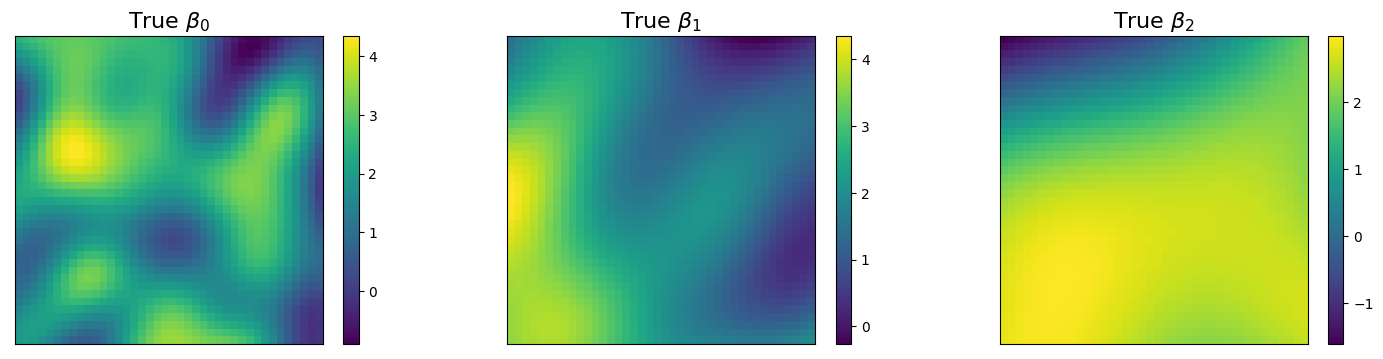

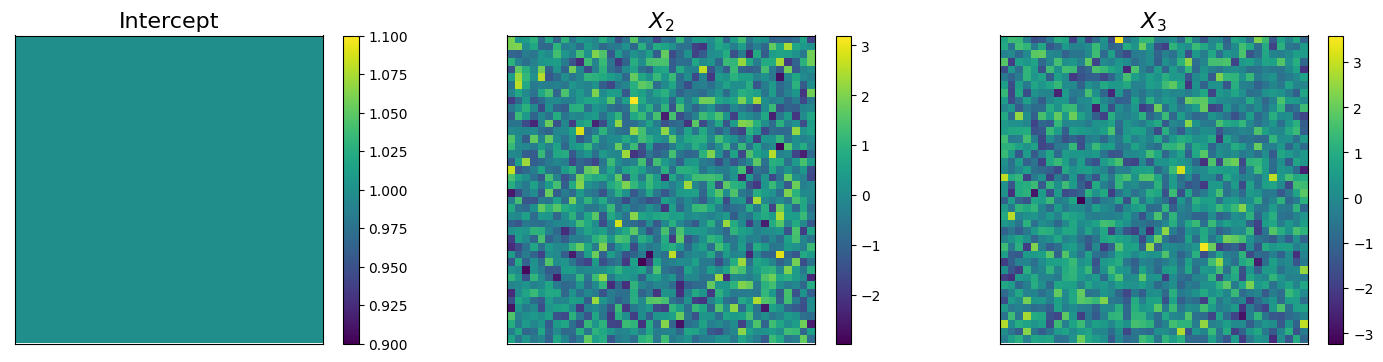

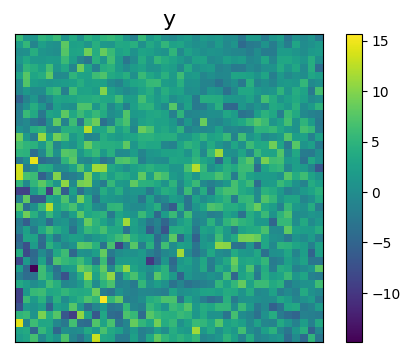

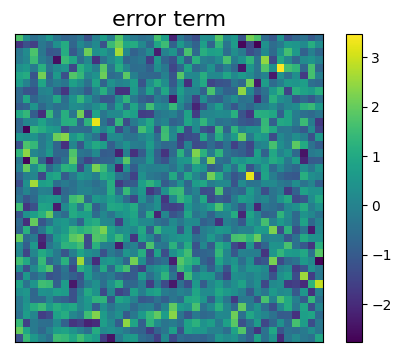

In [2]:
k = 2
field_size = 40

dataset = SimulatedSpatialDataset(
    k=k,
    field_size=field_size
)
[X] = dataset.generate_data()
[beta] = dataset.generate_processes()
[y, err] = dataset.fit_y(X, beta)

dataset.plot(
    b=beta.T,
    sub_title=[r"True $\beta_0$", r"True $\beta_1$", r"True $\beta_2$"],
    size=field_size
)

dataset.plot(
    b=X.T,
    sub_title=[r"Intercept", r"$X_2$", r"$X_3$"],
    size=field_size
)

dataset.plot(
    b=y.reshape(1, -1),
    sub_title=['y'],
    size=field_size
)

dataset.plot(
    b=err.reshape(1, -1),
    sub_title=['error term'],
    size=field_size
)

Create and fit the MGWR model (Official MGWR codebase)

In [3]:
g_X = dataset.X[:, 1:]
g_y = dataset.y.reshape(-1, 1)
g_coords = dataset.coordinates.tolist()

mgwr_selector = Sel_BW(g_coords, g_y, g_X, multi=True)
official_mgwr_bw = mgwr_selector.search(multi_bw_min=[2])
official_mgwr_results = OfficialMGWR(
    g_coords,
    g_y,
    g_X,
    mgwr_selector,
    hat_matrix=True
).exact_fit()
print(official_mgwr_bw)

c:\Users\jim60\anaconda3\envs\lmgwr\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Backfitting:   2%|▏         | 3/200 [00:39<43:32, 13.26s/it]


[ 46. 102.  93.]


Create the MGWR model (lmgwr codebase)

In [4]:
kernel = GwrKernel(dataset, 'bisquare')
refactored_mgwr = MGWR(dataset, kernel)
refactored_mgwr.update_bandwidth_set([46., 102., 93.]).exact_fit()

MGWR : MGWR model is initialized.
GWR : GWR model is initialized.
GWR : GWR model is initialized.
(4800, 3200)
(1600, 9600)


ValueError: operands could not be broadcast together with shapes (1600,3) (1600,9600) 

Compare outputs

In [ ]:
s_matrix_match = np.allclose(refactored_mgwr.S, official_mgwr_results.S)
betas_match = np.allclose(refactored_mgwr.betas, official_mgwr_results.params)

print("="*60)
print("MGWR Model Comparison")
print("="*60)
print(f"{'Metric':30} {'Custom MGWR':>12} {'Official MGWR':>15}")
print("-"*60)
print(f"{'R-squared':30} {refactored_mgwr.r_squared:12.4f} {official_mgwr_results.R2:15.4f}")
print(f"{'AIC':30} {refactored_mgwr.aic:12.2f} {official_mgwr_results.aic:15.2f}")
print(f"{'AICc':30} {refactored_mgwr.aicc:12.2f} {official_mgwr_results.aicc:15.2f}")
print("-"*60)
print(f"{'Coefficient matrices match?':30} {str(betas_match):>12}")
print(f"{'S matrices match?':30} {str(s_matrix_match):>12}")
print("="*60)